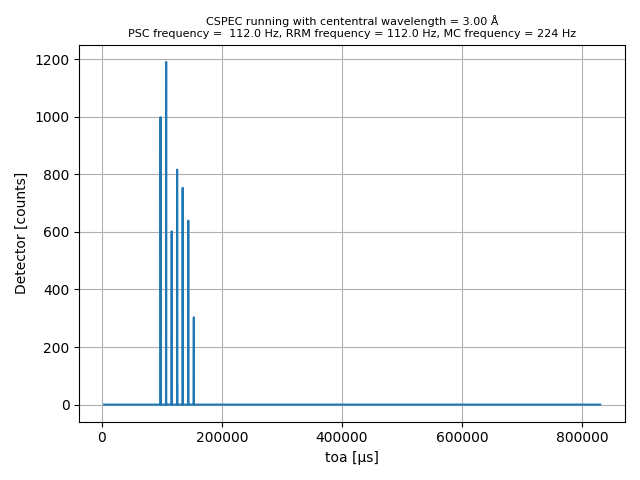

In [1]:
%matplotlib widget
import scipp as sc
from drcspec.instrument import Instrument
from drcspec.components.source import Source
import plopp as pp
import matplotlib.pylab as plt

T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(3.0, unit="Å")
f_M = sc.scalar(224, unit="Hz")
n: int = 2
phase_bw3 = sc.scalar(0.0, unit="deg")

cspec = Instrument(central_wavelength, f_M, n, phase_bw3, t_offset=T_OFFSET)
cspec.source = Source(facility="ess-cspec", neutrons=5_000_000, pulses=1)  # type: ignore
wavelength_requested = cspec.calculate_incoming_wavelength()
res = cspec.run()

hist_det = res.detectors["Detector"].data.hist(toa=5_000)


fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(cspec), fontsize=8)
fig.tight_layout()

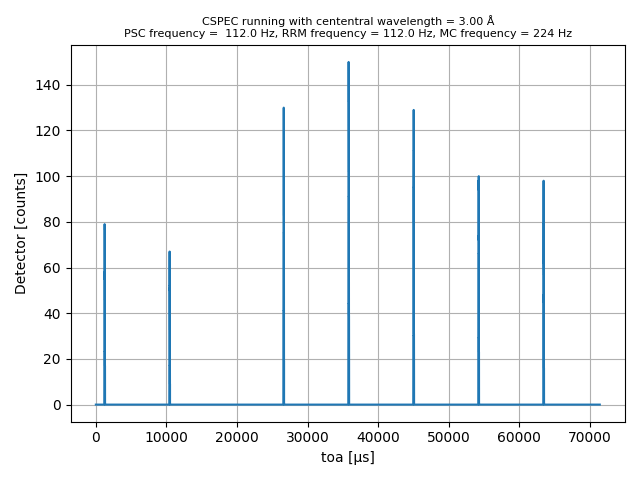

In [2]:
cspec.wrap_frame(res)
hist_det = res.detectors["Detector"].data.hist(toa=10_000)

fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(cspec), fontsize=8)
fig.tight_layout()

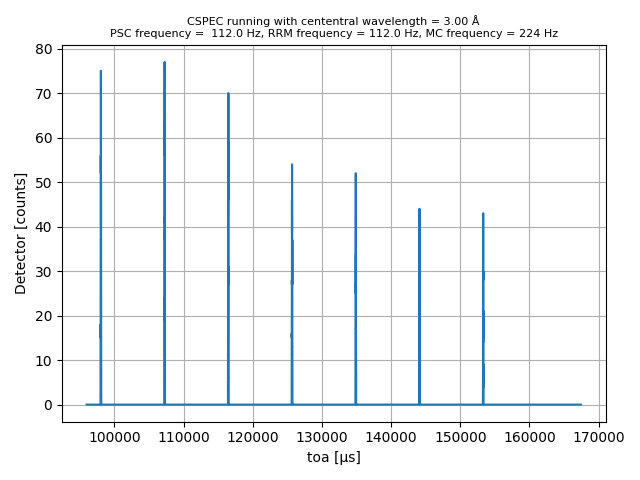

In [3]:
params = cspec.unwrap_frame(res, ei_ef_ratio=0.0)
reduced_list = cspec.toa_to_energy(res, *params)
hist_det = res.detectors["Detector"].data.hist(toa=20_000)

fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(cspec), fontsize=8)
fig.tight_layout()

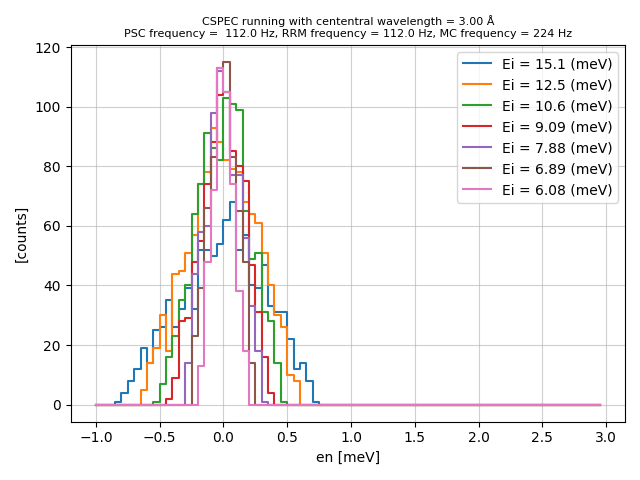

In [4]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -1, 3, 0.05, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(cspec), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

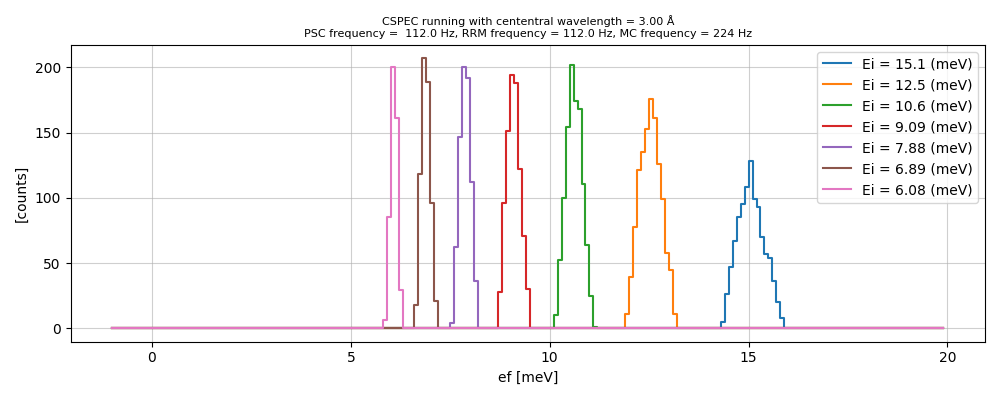

In [5]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", -1, 20, 0.1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(cspec), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

In [6]:
cen = [
    (da.data * sc.midpoints(da.coords["ef"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (da.data * (sc.midpoints(da.coords["ef"] - cen[i].data)) ** 2).sum() / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
print(f"delta en FWHM  = {[round(float(v.data.value), 4) for v in fwhm]} meV")
ratio = [round(float(f.data / c.data), 3) for f, c in zip(fwhm, cen)]
print(f"delta en over ei = {ratio}")

delta en FWHM  = [0.7749, 0.6195, 0.4728, 0.3931, 0.3116, 0.2651, 0.2023] meV
delta en over ei = [0.051, 0.049, 0.045, 0.043, 0.04, 0.038, 0.033]


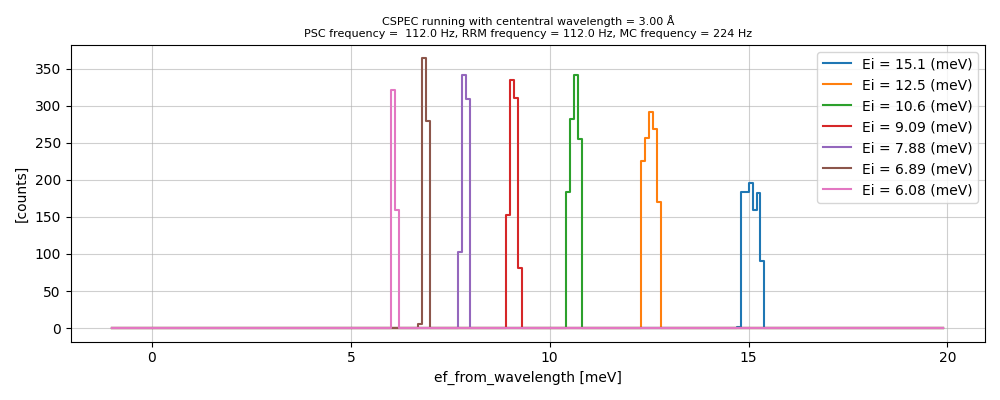

In [7]:
import tof

reduced_list_new = []
for reduced in reduced_list:
    ef_wavelength = tof.utils.wavelength_to_energy(reduced.coords["wavelength"])
    reduced_list_new.append(
        reduced.assign_coords({"ef_from_wavelength": ef_wavelength})
    )

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef_from_wavelength=sc.arange("ef_from_wavelength", -1, 20, 0.1, unit="meV")
    )
    for reduced in reduced_list_new
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(cspec), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

In [8]:
cen = [
    (da.data * sc.midpoints(da.coords["ef_from_wavelength"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (
            da.data * (sc.midpoints(da.coords["ef_from_wavelength"] - cen[i].data)) ** 2
        ).sum()
        / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
ratio = [round(float(f.data / c.data), 4) for f, c in zip(fwhm, cen)]
print(ratio)

[0.0251, 0.0247, 0.0228, 0.0226, 0.0205, 0.0174, 0.0182]
